In [133]:
import numpy as np
from matplotlib import pyplot as plt

In [134]:
#pip install pyoomph

# Simulation
Solve the dynamics
$$\partial_t h = \partial_x Q \partial_x \Pi$$
$$\Pi = -\Delta h+\partial_h W$$
$$Q=h^3/3\eta$$
$$W=A(\chi)w(h);\quad \chi = \epsilon x$$
$$w(h)=h_a^3\frac15 h^{-5}-\frac12 h^{-2}$$

There is no bulk force ($c=0$), while
$$A=A_0+\nabla_{\chi}A \cdot \chi$$
And the inhomogenity is activated at time $t>t_0$, through the activation function $$\theta(t)=\frac12 \{1+\tanh((t-t_0)\sigma^{-1})\};$$
 to leave the system the time to converge to the equilibrium state from the initial condition. In the present simulation

In [135]:
# Parameters of the simulation
eps = 0.001
ha = 0.5

eta = 1
A0 = 1
grad_chiA = 1

t0 = 1e3    # At this time driving is turned ON
def A(x):
    return A0+grad_chiA*float(eps)*x

In [ ]:
# Simulation (call the time solver)
%run -i time_solver.py $eps

In [137]:
# Read hmax(t) and xmax(t) from domain*.txt

import glob
files = sorted(glob.glob("time_solver/domain/domain_*.txt"))

times = []
h_max_list = []
x_at_hmax = []

for file in files:
    # --- Read header line ---
    with open(file, "r") as f:
        header = f.readline()
    
    # Extract time
    # "# coordinate_x h p @time=353.0"
    time_val = float(header.split("@time=")[-1])
    
    # --- Read data with numpy ---
    data = np.loadtxt(file)   # automatically skips lines starting with '#'
    data = np.atleast_2d(data)
    
    x = data[:, 0]
    h = data[:, 1]
    
    # --- Find maximum ---
    idx = np.argmax(h)
    
    times.append(time_val)
    h_max_list.append(h[idx])
    x_at_hmax.append(x[idx])

# Convert to arrays
times = np.array(times)
h_max_list = np.array(h_max_list)
x_at_hmax = np.array(x_at_hmax)


# Measure of $\nabla_{\chi}h_0^{out}$
For $\nabla_{\chi}h_0^{out}$, this is the same on both sides of the droplet and so we measure it during the time simulation. We use a test function $\phi$ that is 1 close to the boundaries and zero outside, such that $\int h(x)\phi(x) dx \alpha \nabla_{\chi}h_0^{out}$ where the multiplication factor is the support of $\phi$. 

In [138]:
# Read grad_x h0out(t) from obx.txt
time, grad_x_h0out = np.loadtxt(
    "time_solver/obs.txt",
    skiprows=1,
    unpack=True
)

# Measure $h_0^{out}$ from $h_{max}$

In the absence of driving and in the limit of large droplets, where $h_0^{out}=h_a+\delta h_0^{out}$
$$\delta h_0^{out}= \frac{w(h_{max})-w(h_a)}{h_{max}-h_a}w''(h_a)^{-1}+O((\delta h_0^{out})^2)$$
Notice that, to leading order, $h_0^{out}$ does not depend on $A(\chi_*)$ but only on $h_{max}$


In [139]:
# Compute h0out and dWh0out
def wetting_pot(h):
        return (ha**3/5*h**(-5) - 1/2*h**(-2))
def dwetting_pot(h):
        return (- ha**3*h**(-6) + h**(-3))
def ddwetting_pot(h):
        return (7*ha**3*h**(-7) - 3*h**(-4))
h0outs = ha + (wetting_pot(h_max_list)-wetting_pot(ha))/(h_max_list-ha)*(1/(ddwetting_pot(ha)))
As=A(x_at_hmax)

# Solve $h_0^{in}$ from $h_0^{out}$ or $h_{max}$ (for each time-step)

## The dependence of $h_0^{in}$ on $A(\chi_*)$ can be absorbed in a rescaling of lengths

Changing variable to $x'=A(\chi_*)^{1/2}x$,
$$-\Delta h_0^{in} +A(\chi_*)w'(h_0^{in}) = A(\chi_*)w'(h_0^{out})$$
becomes
$$-\Delta' h_0^{in} + w'(h_0^{in}) = w'(h_0^{out}(h_{max}))$$
as $$w'(h_0^{out})=w''(h_a)\delta h_0^{out}=\frac{w(h_{max})-w(h_a)}{h_{max}-h_a}$$
Therefore $h_0^{in}(h_{max})$ is a function of $h_{max}$ (or, equivalently, $h_0^{out}$) **only** and does not depend on $A(\chi_*)$ (this dependence has been absorbed in the rescaling).

The solution $h_0^{in}(h_{max})$ is a function of $x'$, therefore when computing the integrals $\hat{\Omega}, I, K$ we change variable $\mathrm{d}x=A(\chi_*)^{-1/2}\mathrm{d}x'$. 


## Solving for $h_0^{in}$
As the RH depends only on $h_{max}$ (or, equivalently, $h_0^{out}$) we label $f(h_{max})=w'(h_0^{out})$, then
$$-\Delta' h_0^{in} + w'(h_0^{in}) = f(h_{max})$$
As I cannot find the non-trivial (droplet) solution (the Newton algorithm converges to the trivial solution $h=h_a$), I regognize that the RH can be interpreted as a Lagrange multiplier for the mass $m=\int h_0^{in} dx$ in a problem where there is no RH term.

Therefore, I can solve 
$$-\Delta' h_0^{in} + w'(h_0^{in})  = 0$$
with a constrained $m$ and then I can do **continuation in $m$** (or in the concentration $c_0=m/L$, where $L$ is the simulation box size).
At each continuation step, I measure $h_{max}$ and I compute the integrals of $h_0^{in}(h_{max})$

$$K'= \int \frac{(\hat{h}_{0}^{in})^2}{(h_{0}^{in})^3}\mathrm{d}x';\quad \hat{\Omega}'=\int  \hat{w}_{0}^{in}\mathrm{d}x';\quad I'=(h_{0}^{out})^3\int \frac{ \hat{h}_{0}^{in}}{(h_{0}^{in})^3}\mathrm{d}x'$$
$$K=A(\chi_*)^{-1/2}K';\quad \hat{\Omega}=A(\chi_*)^{-1/2}\hat{\Omega}';\quad I=A(\chi_*)^{-1/2}I'$$
as $\mathrm{d}x=A(\chi_*)^{-1/2}\mathrm{d}x'$. Then we can **interpolate** the functions $K'(h_{max}), \hat{\Omega}'(h_{max}), I'(h_{max})$ (or, equivalently, as a function of $h_0^{out}$).


---------

The **advantage** of having a mass constraint is that $h=h_a$ is not a solution and you have a sub-critical pitch-fork bifurcation that we can follow to the droplet branch. 

## Bulk force generalization
In the presence of both $A(\chi)$ and a bulk force
$$\partial_h W(h,\chi)=A(\chi)w'(h)-c\chi$$
therefore $c\chi$ is the same both for $\partial_h W_0^{out}$ and $\partial_h W_0^{in}$ so it **simplifies**.

In the presence of a bulk force, only the final formula for $v_1$ sees an extra contribution $+c(m-I)$ (where $m=\int h_0^{in}dx$), while $h_0^{in}(h_{max})$ is computed as if there was no bulk force.


In [140]:
# Read the integrals as a function of h0out or h0in_max from the pde2path continuatiom
data = np.loadtxt(
    "1D_c0_continuation_22_04_26.txt",
    delimiter=',',
    unpack=True
)
numrows = len(data[0,:])
K = data[1:, numrows-1]
I = data[1:, numrows-2]
Omega = data[1:, numrows-3]
h0out_cont = data[1:, numrows-4]
#dWout_cont = data[1:, numrows-5]
hmax_cont = data[1:, numrows-6]
#c0 = data[1:, numrows-7]

#plt.plot(h0out_cont-ha,K,'.-')
#plt.plot(h0out_cont-ha,I,'.-')
#plt.loglog(h0out_cont-ha,Omega,'.-')
#plt.xlabel('$h_0^{out}-h_a$')
#plt.grid()

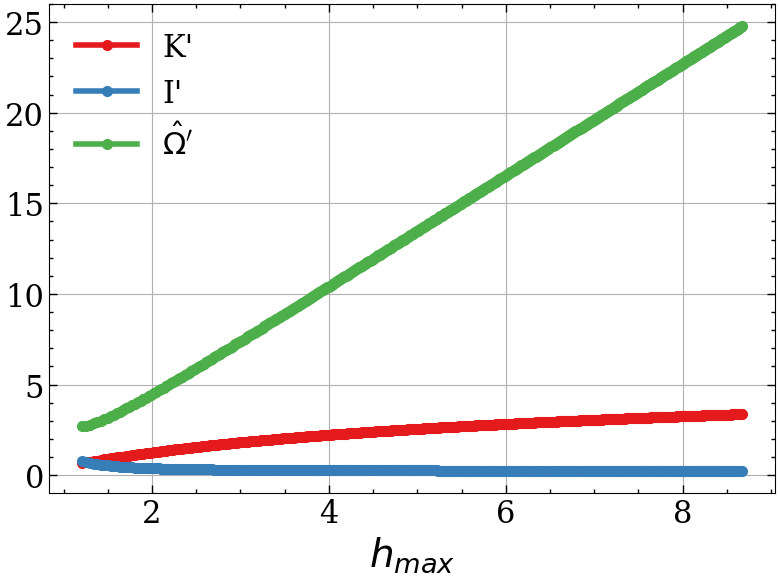

In [141]:
# For the validation is natural to plot v.s. hmax
plt.plot(hmax_cont,K,'.-',label="K'")
plt.plot(hmax_cont,I,'.-',label="I'")
plt.plot(hmax_cont,Omega,'.-',label="$\\hat{\Omega}'$")
plt.xlabel('$h_{max}$')
plt.grid()
plt.legend()

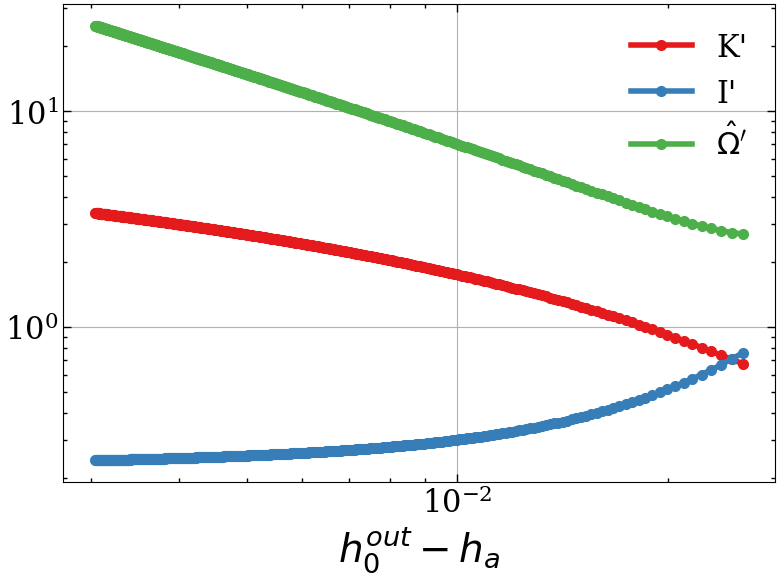

In [142]:
# For applications (where we solve only the outer eq. giving h0out) we plot v.s. h0out
plt.plot(h0out_cont-ha,K,'.-',label="K'")
plt.plot(h0out_cont-ha,I,'.-',label="I'")
plt.loglog(h0out_cont-ha,Omega,'.-',label="$\\hat{\Omega}'$")
plt.xlabel('$h_0^{out}-h_a$')
plt.grid()
plt.legend()

In [ ]:
# Interpolate the integrals I, K , Omega for the measured values of h_max in the simulation
# to compute the predicted value of v1 (for each time-step of the time simulation)
from scipy.interpolate import CubicSpline
I_spline = CubicSpline(hmax_cont, I)
K_spline = CubicSpline(hmax_cont, K)
Omega_spline = CubicSpline(hmax_cont, Omega)

v1s = []
for j in np.arange(0,len(times)):
    # Measurements from Time simulation
    h0out = h0outs[j]
    hmax = h_max_list[j]
    A_droplet = As[j]
    nabla_chi_h0out = grad_x_h0out[j]/eps# chi=eps*x

    I_temp = I_spline(hmax)*A_droplet**(-1/2)   # dx'=A^-1/2 dx
    K_temp = K_spline(hmax)*A_droplet**(-1/2)
    Omega_temp = Omega_spline(hmax)*A_droplet**(-1/2)

    v1 = 1/(3*eta*K_temp)*((-Omega_temp+dwetting_pot(h0out)*I_temp)*grad_chiA+I_temp*ddwetting_pot(h0out)*A_droplet*nabla_chi_h0out)
    v1s.append(v1)


# Validation of the model
$$\dot{\chi}_*=\epsilon^2 v_1\quad (69)$$
As $\chi=\epsilon x$, then $\dot{x}=\epsilon v_1$
$$\dot{x}/\epsilon = v_1$$

Text(0, 0.5, '$x_{max}$')

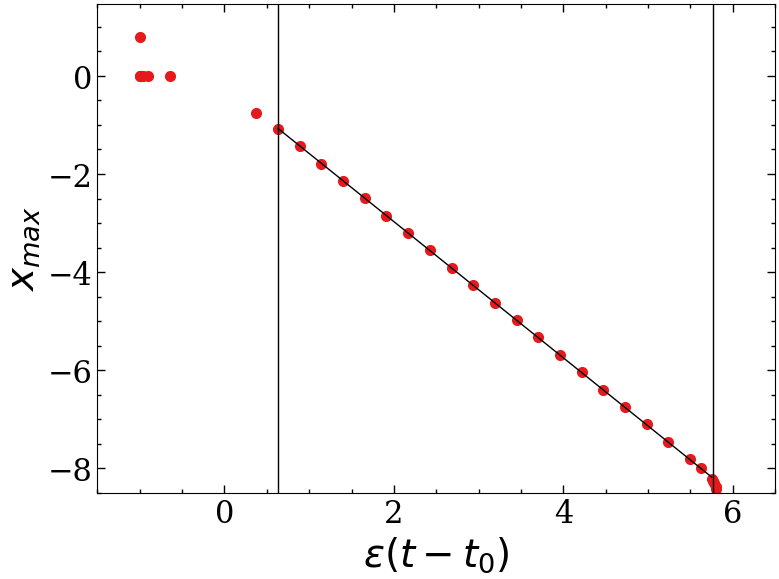

In [144]:
from matplotlib import pyplot as plt

# Measure of droplet position in the Time simulation
plt.plot((times-t0)*eps, x_at_hmax,'.')
imin = 10
imax = 32
plt.axvline((times[imin]-t0)*eps,color='black',lw='1')
plt.axvline((times[imax]-t0)*eps,color='black',lw='1')
tt = (times[imin:imax]-t0)*eps
xx = x_at_hmax[imin:imax]
c = np.polyfit(tt, xx, deg=1)
v1_time_simul = c[0]
plt.plot(tt, c[1]+c[0]*tt,color='black',lw='1')
plt.ylim(bottom=-8.5)
plt.xlim(right=6.5)
plt.xlabel('$\epsilon (t-t_0)$')
plt.ylabel('$x_{max}$')

Text(0, 0.5, '$v_{1}$')

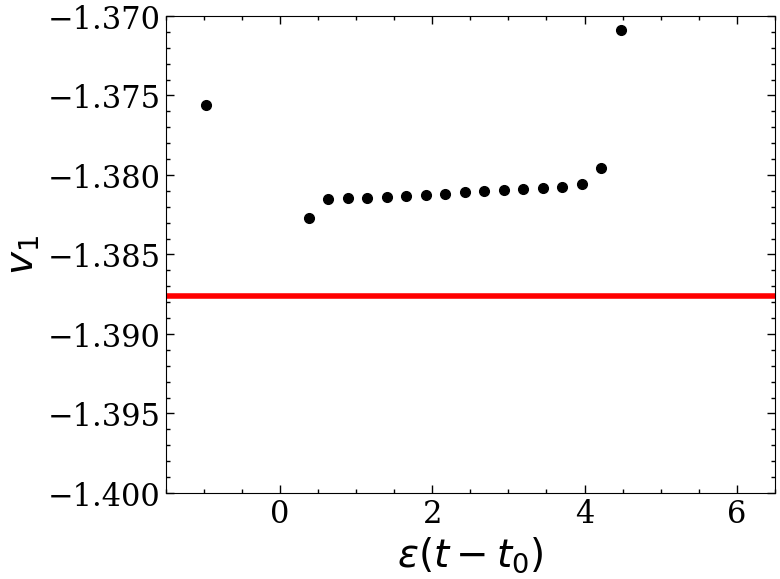

In [145]:
# Compare simulation with model
plt.plot(eps*(times-t0), v1s,'.',color='black')
plt.axhline(v1_time_simul,color='red')
plt.ylim(top=-1.37, bottom=-1.4)
plt.xlim(right=6.5)
plt.xlabel('$\epsilon (t-t_0)$')
plt.ylabel('$v_{1}$')

The growth of $v_1(t)$ is a combined effect of $h_{max}$ and $A(\chi_*)$ dimunushing 

Text(0.5, 0, '$\\epsilon(t-t_0)$')

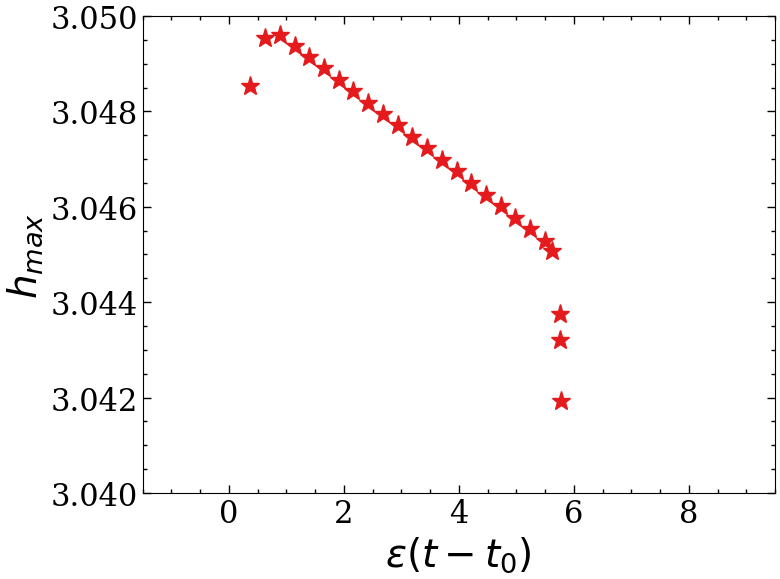

In [146]:
plt.plot(eps*(np.array(times)-t0),h_max_list,'*')
plt.ylim(3.04,3.05)
plt.ylabel('$h_{max}$')
plt.xlabel('$\epsilon(t-t_0)$')

Text(0.5, 0, '$\\epsilon(t-t_0)$')

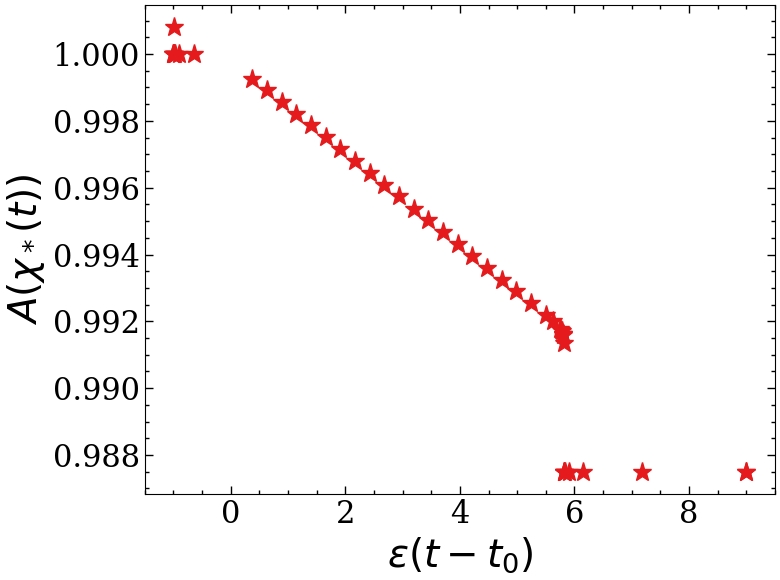

In [147]:
plt.plot(eps*(np.array(times)-t0),As,'*')
plt.ylabel('$A(\chi_*(t))$')
plt.xlabel('$\epsilon(t-t_0)$')